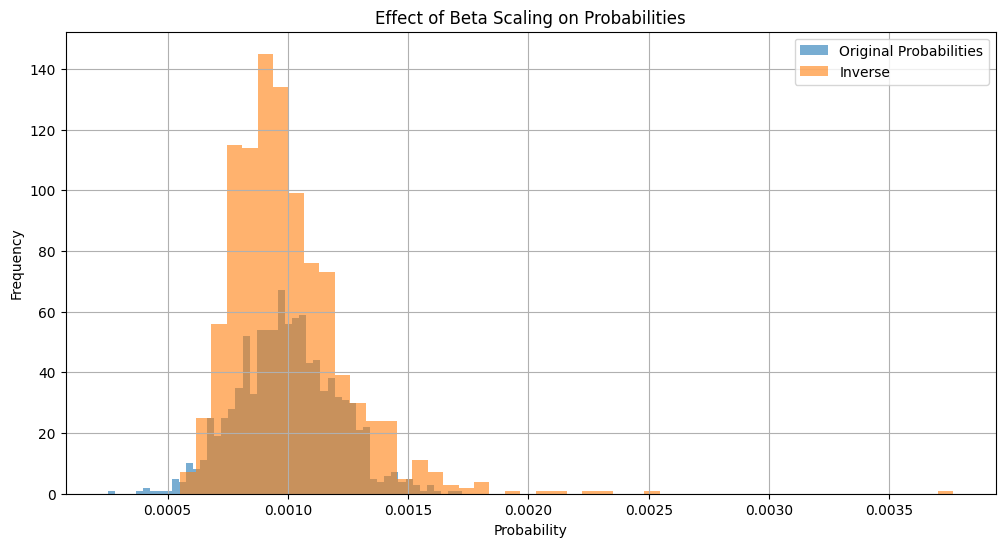

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


betas = [0.3, 0.4, 0.5]  # Example beta values for scaling
# Generate a bell-shaped distribution for original probabilities
mu, sigma = 0.5, 0.1
probs = np.random.normal(mu, sigma, 1000)
probs = np.clip(probs, 0.01, 1)  # Ensure probabilities are within [0.01, 1]
probs /= probs.sum()  # Normalize to sum to 1



# Example code of top-k sampling with beta-adjusted probabilities
top_k = 20  # Example top-k value
vocab_size = len(probs)
token_logits = torch.tensor(probs)

# Plot histogram of original probabilities
plt.figure(figsize=(12, 6))
plt.hist(probs, bins=50, alpha=0.6, label='Original Probabilities')

# # Apply beta scaling and plot histogram
# for beta in betas:
    # scaled_probs = probs ** beta
    # scaled_probs /= scaled_probs.sum()
    # Invert the probabilities (1 - p) and renormalize

# Inverse probability transformation
epsilon = 1e-6  # Small constant to avoid division by zero
scaled_probs = 1 / (probs + epsilon)
scaled_probs = scaled_probs / scaled_probs.sum()
plt.hist(scaled_probs, bins=50, alpha=0.6, label=f'Inverse')

plt.title('Effect of Beta Scaling on Probabilities')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()



# # Compute top-k values and indices
# top_k_values, top_k_indices = torch.topk(token_logits, k=top_k, dim=-1)

# # Compute softmax probabilities over top-k
# logit_probs = torch.nn.functional.softmax(top_k_values, dim=-1)

# # Apply beta scaling for exploration
# explore_noise = 2.0  # Example beta value for exploration
# scaled_probs = logit_probs.pow(explore_noise)
# scaled_probs = scaled_probs / scaled_probs.sum(dim=-1, keepdim=True)

# # Sample from the top-k distribution
# sampled_indices = torch.multinomial(scaled_probs, num_samples=1)
# next_tokens = torch.gather(top_k_indices, dim=-1, index=sampled_indices).squeeze(-1)

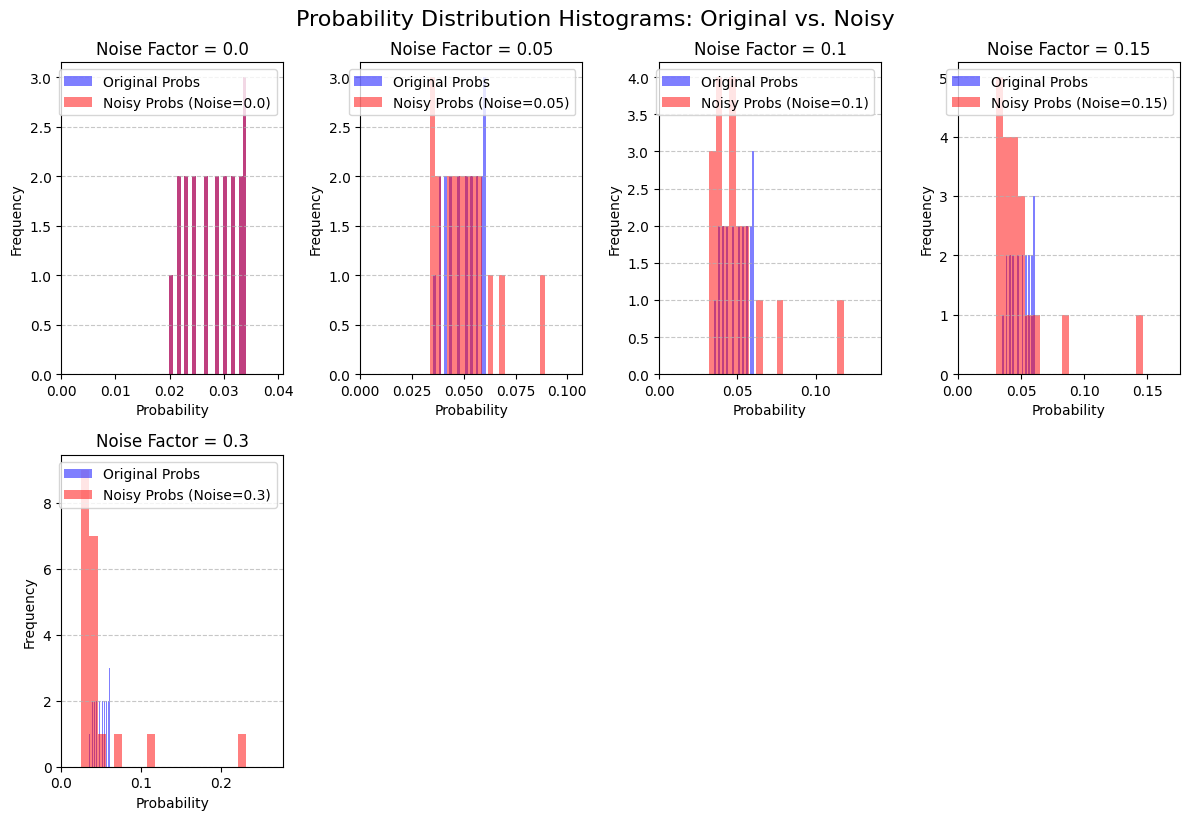

In [15]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def explore_sampling_with_noise(token_logits, explore_top_k, explore_noise_factor=0.1):
    """
    Exploration sampling with noise injection based on inverse ranks.
    (Same code as provided before, but now returns both noisy and original probs)
    """
    vocab_size = token_logits.size(-1)
    do_exploration = explore_top_k > 1 and explore_noise_factor > 0

    if do_exploration:
        top_k = min(explore_top_k, vocab_size)
        top_k_values, top_k_indices = torch.topk(token_logits, k=top_k, dim=-1)
        logit_probs = F.softmax(top_k_values, dim=-1)
        original_probs_np = logit_probs.squeeze(0).cpu().numpy() # Store original probs

        ranks = torch.arange(top_k, dtype=torch.float, device=token_logits.device)
        inverse_ranks = (top_k - 1) - ranks
        noise_values = F.softmax(inverse_ranks, dim=-1)

        noisy_probs = (1.0 - explore_noise_factor) * logit_probs + explore_noise_factor * noise_values
        noisy_probs = noisy_probs / noisy_probs.sum(dim=-1, keepdim=True)
        noisy_probs_np = noisy_probs.squeeze(0).cpu().numpy() # Get noisy probs for plotting

        return noisy_probs_np, original_probs_np # Return both
    else:
        logit_probs = F.softmax(token_logits, dim=-1)
        top_k_values, top_k_indices = torch.topk(logit_probs, k=min(explore_top_k, vocab_size), dim=-1)
        original_probs_np = top_k_values.squeeze(0).cpu().numpy()
        return original_probs_np, original_probs_np # Return original twice for consistent interface


# 1. Generate Sample Logits (Bell-shaped distribution example)
vocab_size = 50  # Reduced vocab size for visualization
top_k = 20       # Explore top 20 tokens
token_indices = torch.arange(vocab_size, dtype=torch.float)
center = vocab_size // 2
std_dev = vocab_size // 6  # Control the spread of the bell curve
token_logits = torch.exp(-((token_indices - center) ** 2) / (2 * std_dev ** 2)).unsqueeze(0) # Gaussian-like logits


# 2. Define Noise Factors to Test
noise_factors = [0.0, 0.05, 0.1, 0.15, 0.3]

# 3. Generate and Plot Histograms
plt.figure(figsize=(12, 8))

for i, noise_factor in enumerate(noise_factors):
    noisy_probs_np, original_probs_np = explore_sampling_with_noise(token_logits, top_k, noise_factor) # Get both probs

    plt.subplot(2, 4, i + 1) # Create subplots for each noise factor
    plt.hist(original_probs_np, bins=20, alpha=0.5, label='Original Probs', color='blue') # Plot original probs in blue
    plt.hist(noisy_probs_np, bins=20, alpha=0.5, label=f'Noisy Probs (Noise={noise_factor})', color='red') # Plot noisy probs in red
    plt.title(f'Noise Factor = {noise_factor}')
    plt.xlabel('Probability')
    plt.ylabel('Frequency')
    plt.xlim(0, max(np.max(original_probs_np), np.max(noisy_probs_np)) * 1.2) # Adjust x-axis limits to fit both
    plt.legend(loc='upper right') # Adjust legend location for better fit
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Probability Distribution Histograms: Original vs. Noisy', fontsize=16, y=1.02)
plt.show()